# 🏦 FinGuard AI — Exploratory Data Analysis

### AI-Powered Financial Fraud Detection & Risk Intelligence Platform

**Notebook:** 02 — Exploratory Data Analysis  
**Project:** FinGuard AI  
**Dataset:** Credit Card Transactions  
**Analysis Type:** Exploratory Data Analysis (EDA)

---

#### 1. Objective

This notebook performs a comprehensive exploratory analysis of the FinGuard AI
credit card transaction dataset.

The objectives are:

- Understand dataset structure
- Analyze transaction distributions
- Study fraudulent vs legitimate transactions
- Analyze transaction amount behavior
- Analyze temporal transaction patterns
- Examine feature distributions
- Identify outliers
- Analyze correlations
- Investigate class imbalance
- Identify fraud-specific behavioral patterns
- Generate publication-quality EDA figures

##### Important

The original raw dataset will **not** be modified in this notebook.

All transformations and preprocessing will be performed in later notebooks.

#### 2. EDA Environment Setup

In [1]:
# ============================================================
# EDA Environment Setup
# ============================================================

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110

print("=" * 70)
print("FIN GUARD AI — EXPLORATORY DATA ANALYSIS")
print("=" * 70)
print(f"Python Version : {sys.version.split()[0]}")
print(f"NumPy Version  : {np.__version__}")
print(f"Pandas Version : {pd.__version__}")
print("=" * 70)

FIN GUARD AI — EXPLORATORY DATA ANALYSIS
Python Version : 3.11.15
NumPy Version  : 2.4.6
Pandas Version : 3.0.5


#### 3. Project Paths

In [2]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "Dataset"
RAW_DATA_DIR = DATASET_DIR / "Raw"

REPORTS_DIR = PROJECT_ROOT / "Reports"
EDA_DIR = REPORTS_DIR / "EDA"
FIGURES_DIR = EDA_DIR / "Figures"

# Create output directories
EDA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = RAW_DATA_DIR / "creditcard.csv"

print("Project Paths")
print("=" * 70)
print(f"Project Root : {PROJECT_ROOT}")
print(f"Raw Dataset  : {RAW_DATA_PATH}")
print(f"EDA Reports  : {EDA_DIR}")
print(f"Figures      : {FIGURES_DIR}")

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{RAW_DATA_PATH}"
    )

print("\n✓ Dataset path validated successfully.")

Project Paths
Project Root : C:\Users\viqua\Desktop\FinGuard AI
Raw Dataset  : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Raw\creditcard.csv
EDA Reports  : C:\Users\viqua\Desktop\FinGuard AI\Reports\EDA
Figures      : C:\Users\viqua\Desktop\FinGuard AI\Reports\EDA\Figures

✓ Dataset path validated successfully.


#### 4. Load Dataset

In [3]:
# ============================================================
# Load Raw Dataset
# ============================================================

df = pd.read_csv(RAW_DATA_PATH)

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")
print(f"Memory  : {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

DATASET LOADED SUCCESSFULLY
Rows    : 284,807
Columns : 31
Memory  : 67.36 MB


#### 5. Dataset Overview

In [4]:
# ============================================================
# Dataset Preview
# ============================================================

print("First 10 Transactions")
display(df.head(10))

print("\nLast 10 Transactions")
display(df.tail(10))

First 10 Transactions


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0



Last 10 Transactions


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284797,172782.0,-0.241923,0.712247,0.399806,-0.463406,0.244531,-1.343668,0.929369,-0.206210,0.106234,-0.284708,-0.612982,-0.066655,-0.732987,0.237948,-0.293959,-0.245496,-0.174846,-0.891169,-0.290491,-0.139512,-0.228876,-0.514376,0.279598,0.371441,-0.559238,0.113144,0.131507,0.081265,5.49,0
284798,172782.0,0.219529,0.881246,-0.635891,0.960928,-0.152971,-1.014307,0.427126,0.121340,-0.285670,-0.111640,-1.109232,-0.453235,-1.046946,1.122674,1.243518,-1.431897,0.939328,-0.002373,2.894952,0.006666,0.099936,0.337120,0.251791,0.057688,-1.508368,0.144023,0.181205,0.215243,24.05,0
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,-0.594242,-1.264072,0.453596,-0.243142,-0.858719,-0.766554,-0.644646,0.447184,0.388721,0.792135,0.348176,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,0.267772,0.523316,0.559047,-0.834660,0.626211,-0.541494,0.225361,-0.605252,-0.163049,0.561695,-0.256922,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,-0.657422,0.644837,0.190916,-0.546329,-0.731707,-0.808036,0.599628,0.070441,0.373110,0.128904,0.000676,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
# ============================================================
# Dataset Information
# ============================================================

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print(f"Total Rows    : {df.shape[0]:,}")
print(f"Total Columns : {df.shape[1]}")

print("\nColumn Names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

DATASET INFORMATION
Total Rows    : 284,807
Total Columns : 31

Column Names:
01. Time
02. V1
03. V2
04. V3
05. V4
06. V5
07. V6
08. V7
09. V8
10. V9
11. V10
12. V11
13. V12
14. V13
15. V14
16. V15
17. V16
18. V17
19. V18
20. V19
21. V20
22. V21
23. V22
24. V23
25. V24
26. V25
27. V26
28. V27
29. V28
30. Amount
31. Class

Data Types:


,Data Type
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [6]:
# ============================================================
# Statistical Summary
# ============================================================

print("=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

display(df.describe().T)

STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


#### 6. Data Quality Analysis

In [7]:
# ============================================================
# Missing Value Analysis
# ============================================================

missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing Percentage": (missing.values / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    "Missing Values",
    ascending=False
)

display(missing_summary)

print(f"Total Missing Values: {df.isnull().sum().sum():,}")

,Column,Missing Values,Missing Percentage
0,Time,0,0.0
1,V1,0,0.0
2,V2,0,0.0
3,V3,0,0.0
4,V4,0,0.0
5,V5,0,0.0
6,V6,0,0.0
7,V7,0,0.0
8,V8,0,0.0
9,V9,0,0.0


Total Missing Values: 0


In [8]:
# ============================================================
# Duplicate Analysis
# ============================================================

duplicate_count = df.duplicated().sum()

print("=" * 70)
print("DUPLICATE TRANSACTION ANALYSIS")
print("=" * 70)
print(f"Duplicate Rows : {duplicate_count:,}")
print(f"Duplicate Rate : {(duplicate_count / len(df)) * 100:.4f}%")

DUPLICATE TRANSACTION ANALYSIS
Duplicate Rows : 1,081
Duplicate Rate : 0.3796%


In [9]:
# ============================================================
# Infinite Value Analysis
# ============================================================

numeric_df = df.select_dtypes(include=np.number)
infinite_count = np.isinf(numeric_df).sum().sum()

print("=" * 70)
print("INFINITE VALUE CHECK")
print("=" * 70)
print(f"Infinite Values : {infinite_count:,}")

INFINITE VALUE CHECK
Infinite Values : 0


#### 7. Target Variable Analysis

The target variable is `Class`.

- `0` → Legitimate Transaction
- `1` → Fraudulent Transaction

Because financial fraud is a highly imbalanced classification problem,
class distribution is a critical part of the analysis.

In [10]:
# ============================================================
# Target Distribution
# ============================================================

target_counts = df["Class"].value_counts().sort_index()

target_summary = pd.DataFrame({
    "Class": target_counts.index,
    "Transaction Count": target_counts.values,
    "Percentage": (target_counts.values / len(df)) * 100
})

target_summary["Transaction Type"] = target_summary["Class"].map({
    0: "Legitimate",
    1: "Fraudulent"
})

target_summary = target_summary[
    ["Class", "Transaction Type", "Transaction Count", "Percentage"]
]

display(target_summary)

fraud_count = int((df["Class"] == 1).sum())
legitimate_count = int((df["Class"] == 0).sum())

print(f"Legitimate Transactions : {legitimate_count:,}")
print(f"Fraudulent Transactions : {fraud_count:,}")
print(f"Fraud Rate              : {(fraud_count / len(df)) * 100:.4f}%")

,Class,Transaction Type,Transaction Count,Percentage
0,0,Legitimate,284315,99.827251
1,1,Fraudulent,492,0.172749


Legitimate Transactions : 284,315
Fraudulent Transactions : 492
Fraud Rate              : 0.1727%


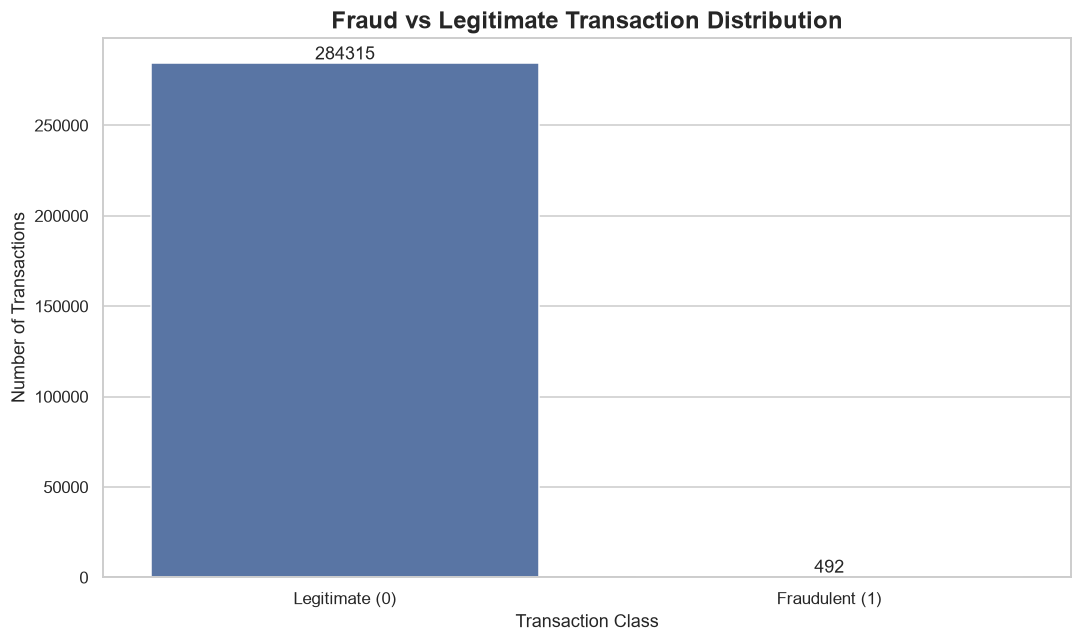

In [11]:
# ============================================================
# Class Distribution
# ============================================================

plt.figure(figsize=(10, 6))

ax = sns.countplot(data=df, x="Class")

ax.set_title(
    "Fraud vs Legitimate Transaction Distribution",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Transaction Class")
ax.set_ylabel("Number of Transactions")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Legitimate (0)", "Fraudulent (1)"])

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "01_Class_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

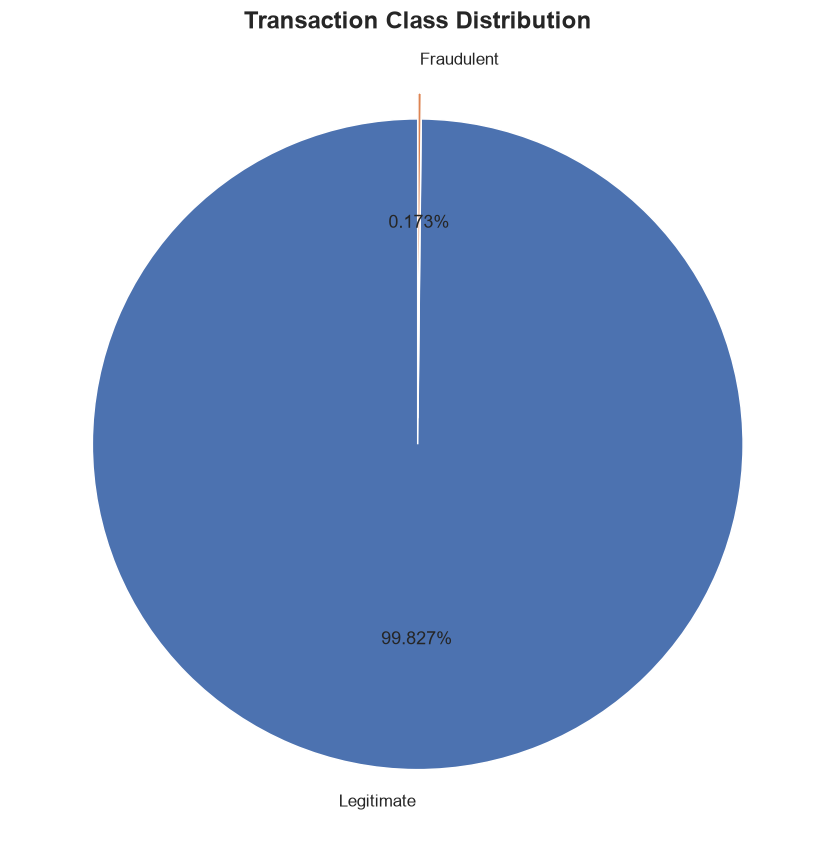

In [12]:
# ============================================================
# Class Distribution — Pie Chart
# ============================================================

labels = ["Legitimate", "Fraudulent"]
sizes = [legitimate_count, fraud_count]

plt.figure(figsize=(8, 8))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.3f%%",
    startangle=90,
    explode=(0, 0.08)
)

plt.title(
    "Transaction Class Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "02_Class_Distribution_Pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 8. Transaction Amount Analysis

In [13]:
# ============================================================
# Amount Statistics by Class
# ============================================================

amount_summary = df.groupby("Class")["Amount"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

amount_summary["Transaction Type"] = [
    "Legitimate",
    "Fraudulent"
]

display(amount_summary)

,count,mean,median,std,min,max,Transaction Type
Class,,,,,,,
0,284315,88.291022,22.00,250.105092,0.0,25691.16,Legitimate
1,492,122.211321,9.25,256.683288,0.0,2125.87,Fraudulent


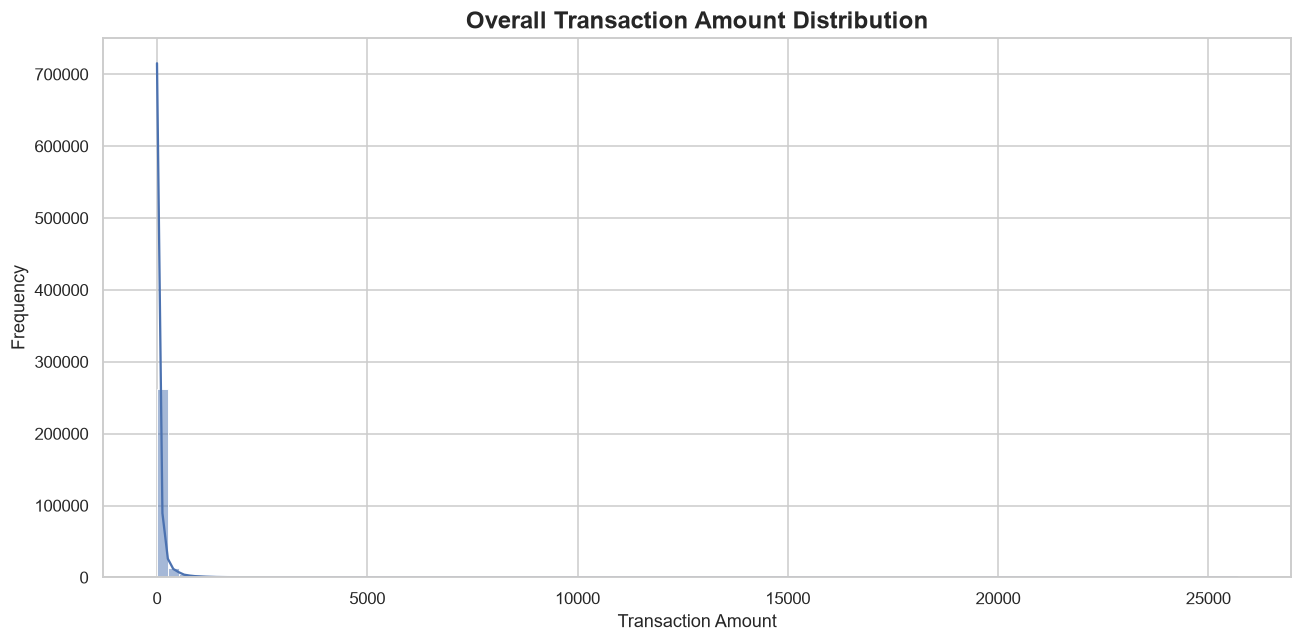

In [14]:
# ============================================================
# Transaction Amount Distribution
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Amount",
    bins=100,
    kde=True
)

plt.title(
    "Overall Transaction Amount Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "03_Transaction_Amount_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

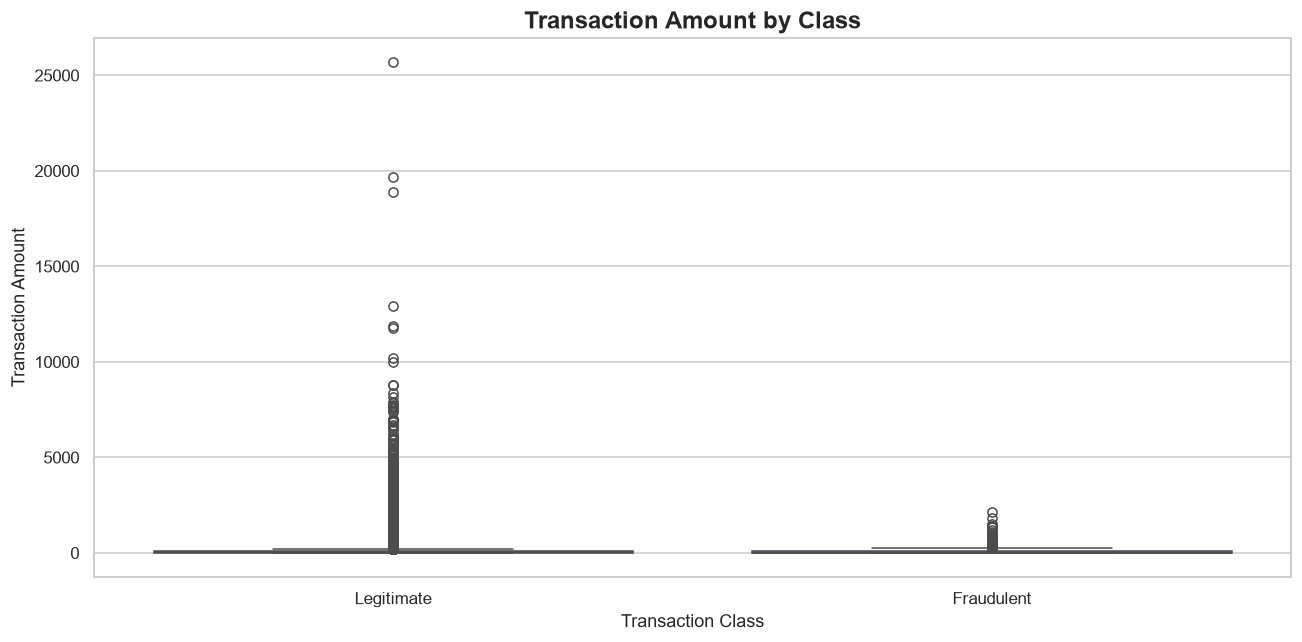

In [15]:
# ============================================================
# Transaction Amount by Class
# ============================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title(
    "Transaction Amount by Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_Amount_by_Class_Boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 9. Temporal Transaction Analysis

The `Time` feature represents elapsed time between transactions.

Temporal analysis can reveal whether fraudulent activity exhibits different
patterns from legitimate transactions.

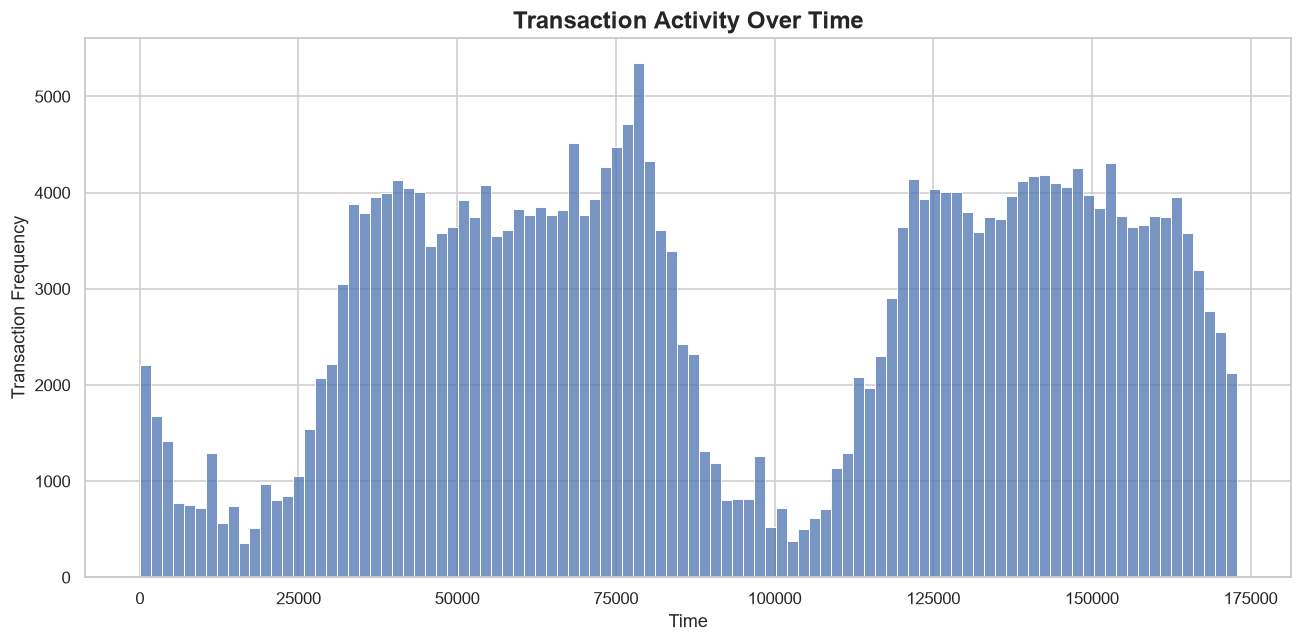

In [16]:
# ============================================================
# Overall Time Distribution
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Time",
    bins=100
)

plt.title(
    "Transaction Activity Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel("Transaction Frequency")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "05_Time_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

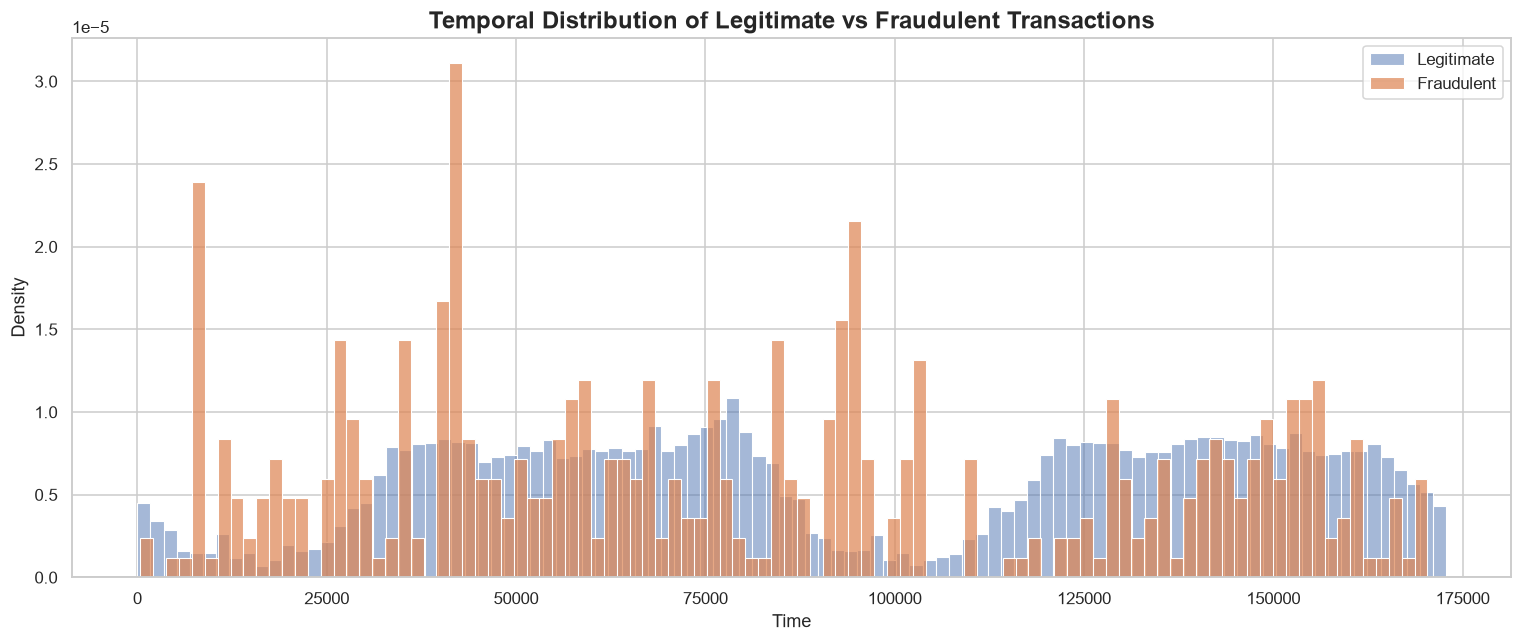

In [17]:
# ============================================================
# Time Distribution by Class
# ============================================================

plt.figure(figsize=(14, 6))

sns.histplot(
    data=df[df["Class"] == 0],
    x="Time",
    bins=100,
    stat="density",
    alpha=0.5,
    label="Legitimate"
)

sns.histplot(
    data=df[df["Class"] == 1],
    x="Time",
    bins=100,
    stat="density",
    alpha=0.7,
    label="Fraudulent"
)

plt.title(
    "Temporal Distribution of Legitimate vs Fraudulent Transactions",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "06_Temporal_Fraud_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 10. Feature Distribution Analysis

In [18]:
# ============================================================
# Identify PCA Features
# ============================================================

feature_columns = [
    column for column in df.columns
    if column.startswith("V")
]

print(f"Number of anonymized PCA features: {len(feature_columns)}")
print("\nFeatures:")
print(feature_columns)

Number of anonymized PCA features: 28

Features:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


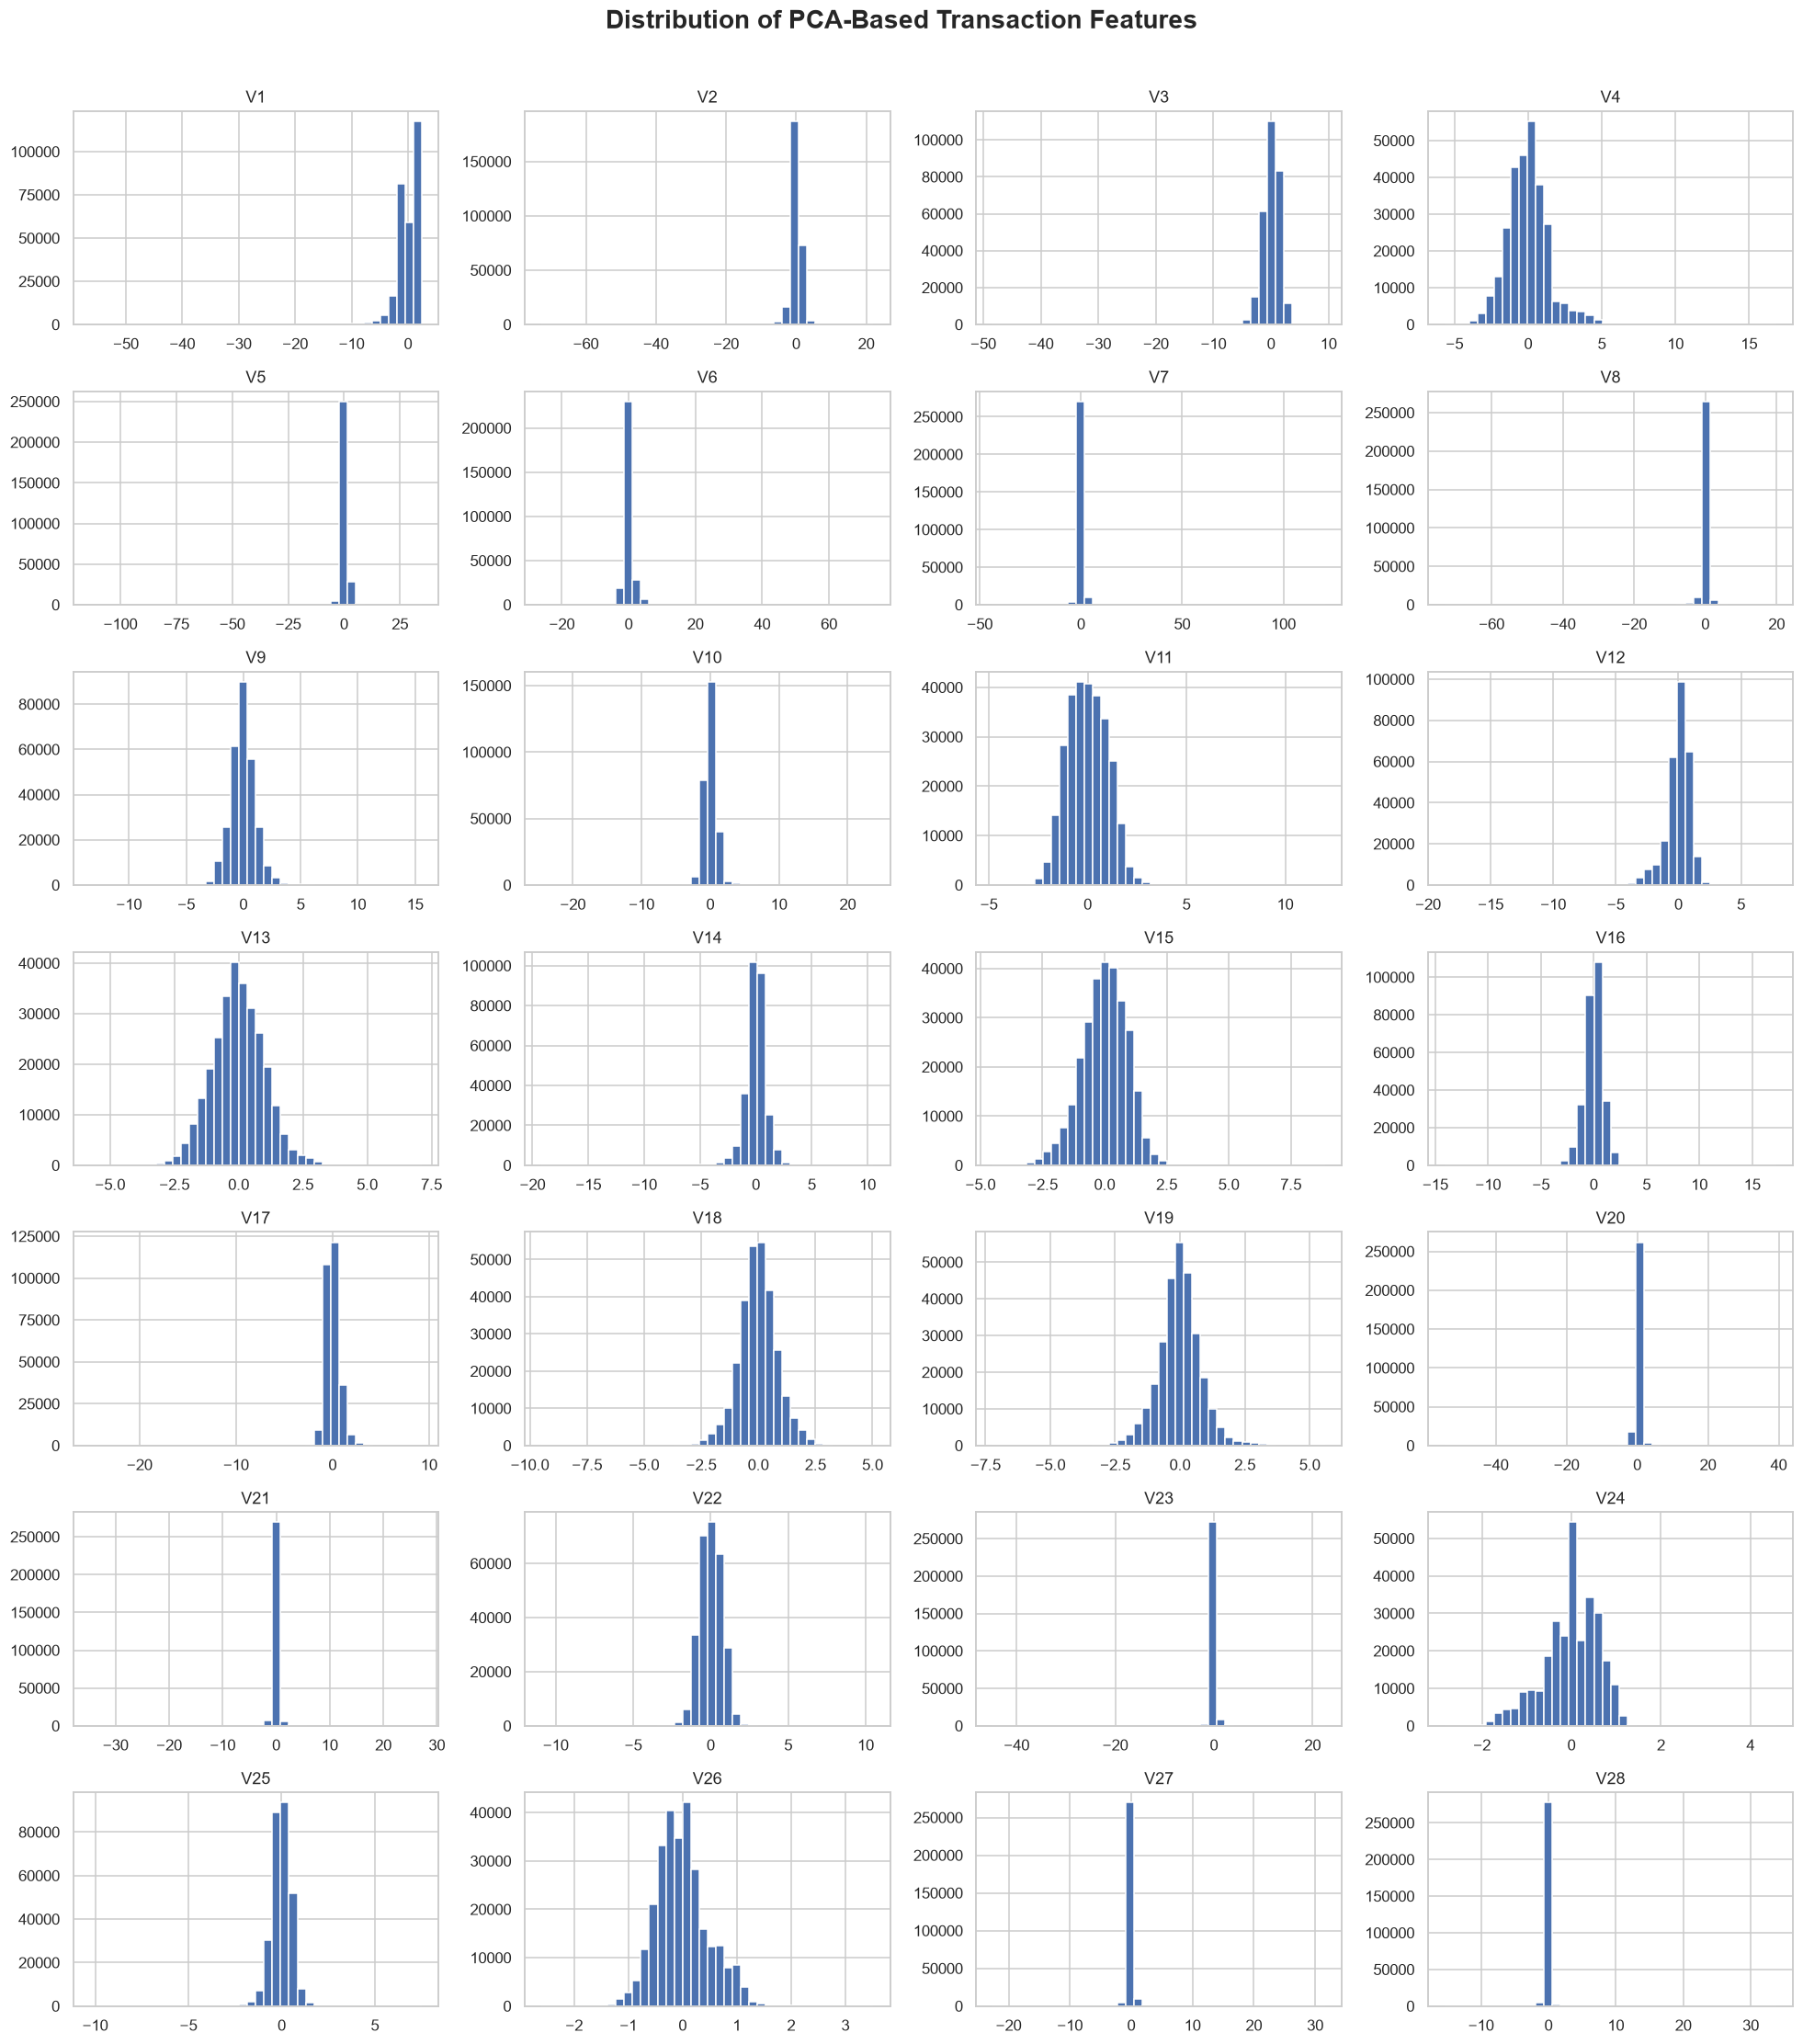

In [19]:
# ============================================================
# PCA Feature Distributions
# ============================================================

df[feature_columns].hist(
    bins=40,
    figsize=(18, 20),
    layout=(7, 4)
)

plt.suptitle(
    "Distribution of PCA-Based Transaction Features",
    fontsize=18,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "07_PCA_Feature_Distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 11. Correlation Analysis

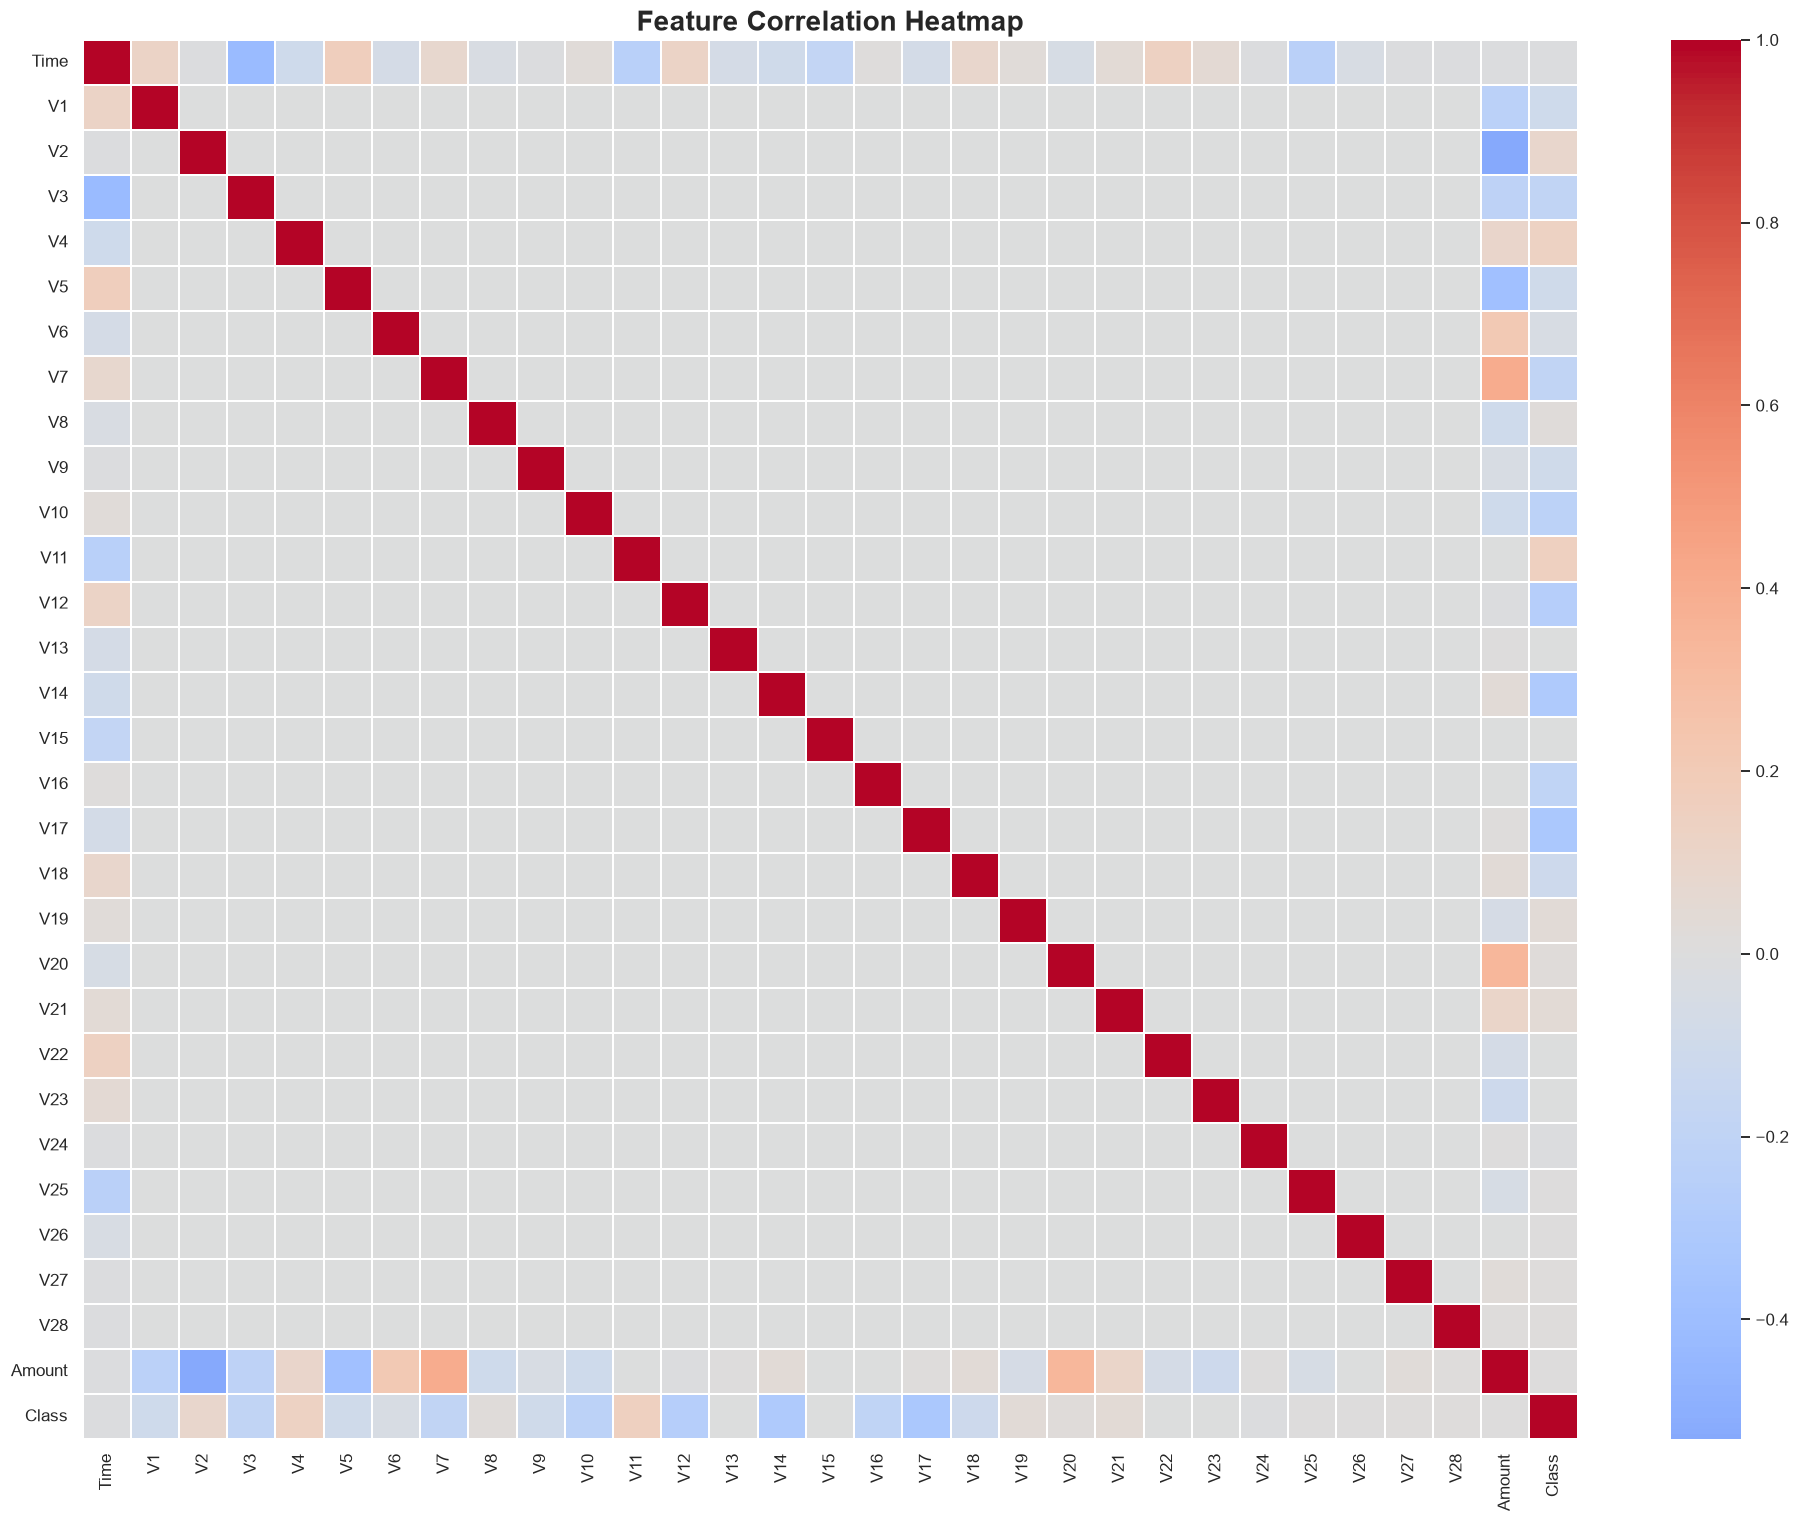

In [20]:
# ============================================================
# Correlation Matrix
# ============================================================

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "08_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# ============================================================
# Correlation with Target
# ============================================================

target_correlation = (
    correlation_matrix["Class"]
    .drop("Class")
    .sort_values(key=abs, ascending=False)
)

target_correlation_df = target_correlation.to_frame(
    "Correlation with Class"
)

display(target_correlation_df)

,Correlation with Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


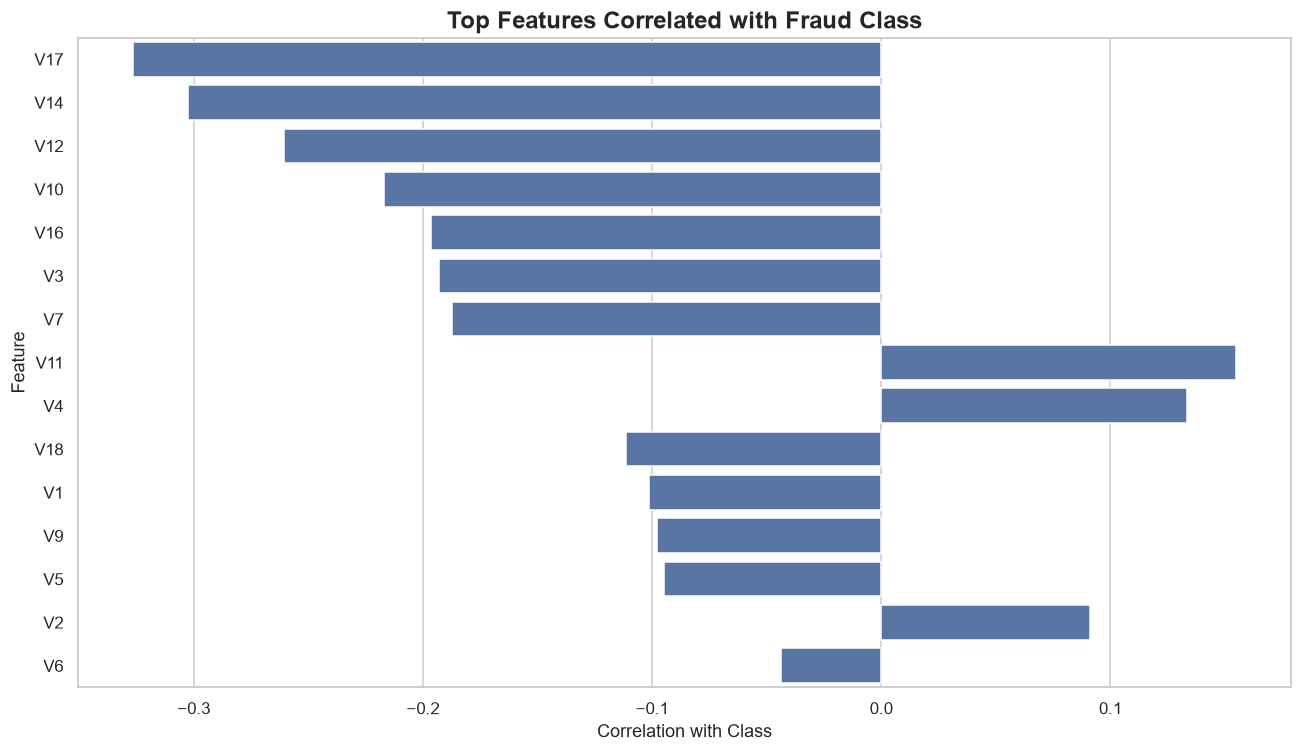

In [22]:
# ============================================================
# Top Target Correlations
# ============================================================

top_correlations = target_correlation.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_correlations.values,
    y=top_correlations.index
)

plt.title(
    "Top Features Correlated with Fraud Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "09_Top_Target_Correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 12. Fraud-Specific Feature Analysis

In [23]:
# ============================================================
# Fraud vs Legitimate Feature Means
# ============================================================

class_means = df.groupby("Class")[feature_columns].mean().T

class_means.columns = [
    "Legitimate Mean",
    "Fraudulent Mean"
]

class_means["Absolute Difference"] = abs(
    class_means["Fraudulent Mean"] -
    class_means["Legitimate Mean"]
)

class_means = class_means.sort_values(
    "Absolute Difference",
    ascending=False
)

display(class_means.head(15))

,Legitimate Mean,Fraudulent Mean,Absolute Difference
V3,0.012171,-7.033281,7.045452
V14,0.012064,-6.971723,6.983787
V17,0.011535,-6.665836,6.677371
V12,0.010832,-6.259393,6.270225
V10,0.009824,-5.676883,5.686707
V7,0.009637,-5.568731,5.578368
V1,0.008258,-4.771948,4.780206
V4,-0.007860,4.542029,4.549889
V16,0.007164,-4.139946,4.147110
V11,-0.006576,3.800173,3.806749


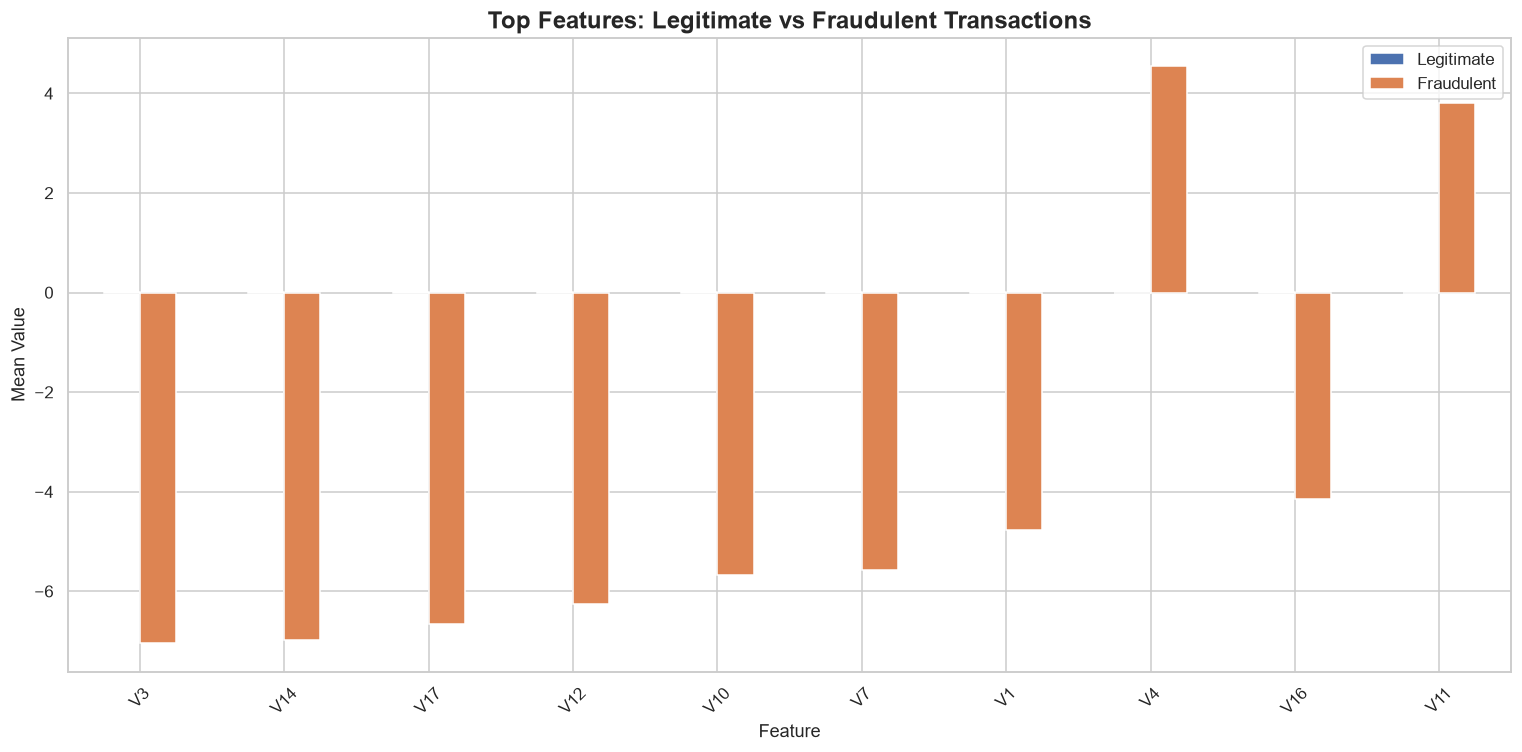

In [24]:
# ============================================================
# Top Fraud-Differentiating Features
# ============================================================

top_features = class_means.head(10).index

comparison_data = df.groupby("Class")[top_features].mean().T

comparison_data.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Top Features: Legitimate vs Fraudulent Transactions",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.legend(["Legitimate", "Fraudulent"])

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "10_Fraud_Feature_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 13. Outlier Analysis

In [25]:
# ============================================================
# Amount Outlier Analysis using IQR
# ============================================================

Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

amount_outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print("=" * 70)
print("TRANSACTION AMOUNT OUTLIER ANALYSIS")
print("=" * 70)
print(f"Q1              : {Q1:.4f}")
print(f"Q3              : {Q3:.4f}")
print(f"IQR             : {IQR:.4f}")
print(f"Lower Bound     : {lower_bound:.4f}")
print(f"Upper Bound     : {upper_bound:.4f}")
print(f"Outlier Count   : {len(amount_outliers):,}")
print(f"Outlier Rate    : {(len(amount_outliers) / len(df)) * 100:.4f}%")

TRANSACTION AMOUNT OUTLIER ANALYSIS
Q1              : 5.6000
Q3              : 77.1650
IQR             : 71.5650
Lower Bound     : -101.7475
Upper Bound     : 184.5125
Outlier Count   : 31,904
Outlier Rate    : 11.2020%


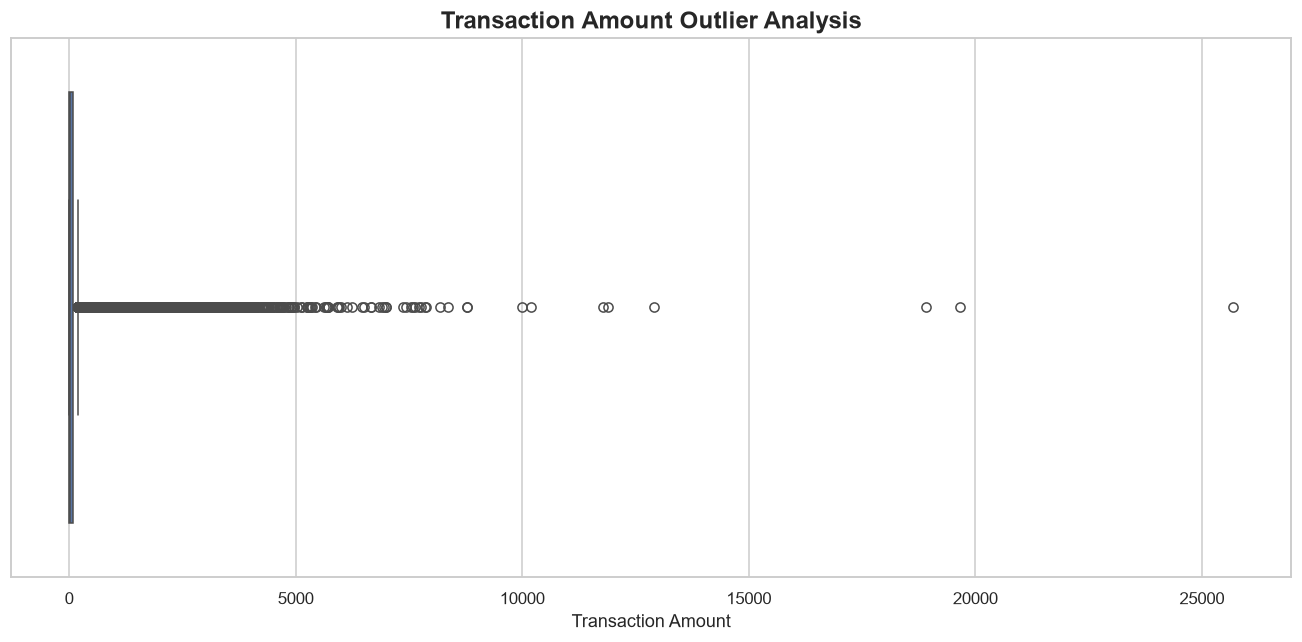

In [26]:
# ============================================================
# Amount Outlier Visualization
# ============================================================

plt.figure(figsize=(12, 6))

sns.boxplot(x=df["Amount"])

plt.title(
    "Transaction Amount Outlier Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Amount")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "11_Amount_Outlier_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 14. Fraud Transaction Amount Analysis

In [27]:
# ============================================================
# Fraud Transaction Amount Statistics
# ============================================================

fraud_transactions = df[df["Class"] == 1].copy()

print("=" * 70)
print("FRAUD TRANSACTION ANALYSIS")
print("=" * 70)
print(f"Fraud Transactions : {len(fraud_transactions):,}")
print(f"Average Amount     : {fraud_transactions['Amount'].mean():.4f}")
print(f"Median Amount      : {fraud_transactions['Amount'].median():.4f}")
print(f"Minimum Amount     : {fraud_transactions['Amount'].min():.4f}")
print(f"Maximum Amount     : {fraud_transactions['Amount'].max():.4f}")

FRAUD TRANSACTION ANALYSIS
Fraud Transactions : 492
Average Amount     : 122.2113
Median Amount      : 9.2500
Minimum Amount     : 0.0000
Maximum Amount     : 2125.8700


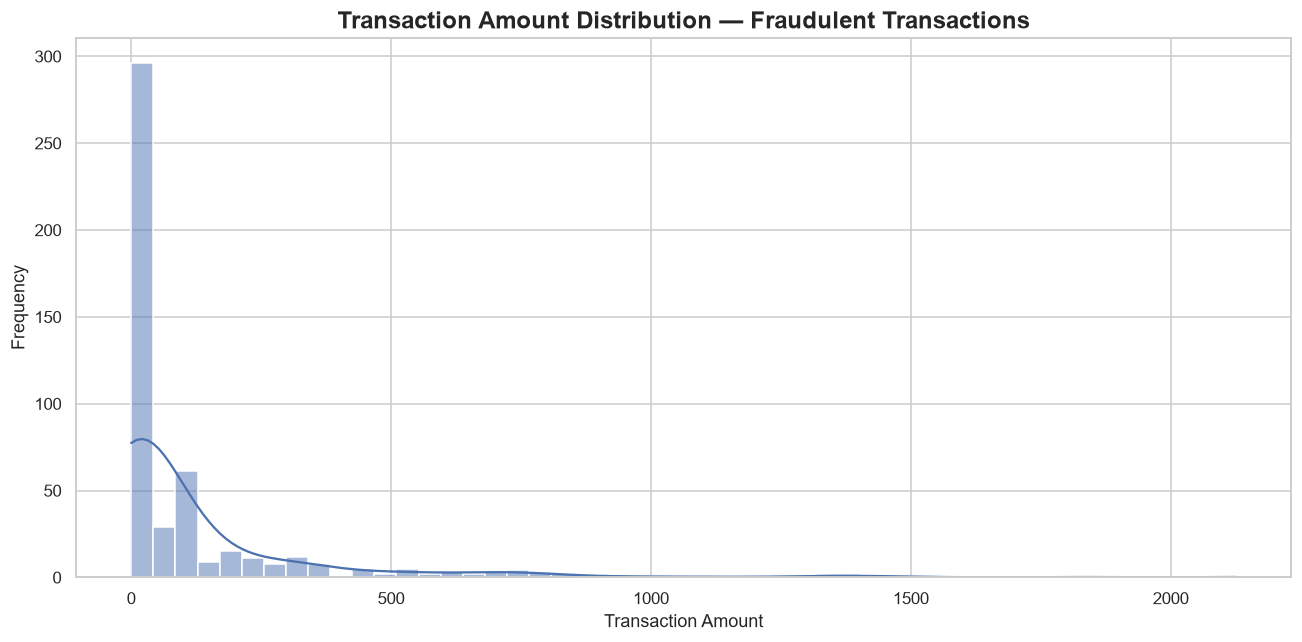

In [28]:
# ============================================================
# Fraud Amount Distribution
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    fraud_transactions["Amount"],
    bins=50,
    kde=True
)

plt.title(
    "Transaction Amount Distribution — Fraudulent Transactions",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "12_Fraud_Amount_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 15. EDA Findings

The major findings from the exploratory analysis are summarized through:

1. Dataset structure
2. Data quality
3. Fraud class imbalance
4. Transaction amount behavior
5. Temporal patterns
6. Feature distributions
7. Correlation patterns
8. Fraud-specific behavior
9. Outlier behavior

These findings will guide the preprocessing and feature engineering stages.

In [29]:
# ============================================================
# EDA Summary
# ============================================================

print("=" * 75)
print("FIN GUARD AI — EDA SUMMARY")
print("=" * 75)

print(f"✓ Total Transactions       : {len(df):,}")
print(f"✓ Total Features           : {df.shape[1]}")
print(f"✓ Fraudulent Transactions  : {fraud_count:,}")
print(f"✓ Legitimate Transactions  : {legitimate_count:,}")
print(f"✓ Fraud Rate               : {(fraud_count / len(df)) * 100:.4f}%")
print(f"✓ Missing Values           : {df.isnull().sum().sum():,}")
print(f"✓ Duplicate Rows           : {duplicate_count:,}")
print(f"✓ Infinite Values          : {infinite_count:,}")
print(f"✓ Amount Outliers          : {len(amount_outliers):,}")

print("\n✓ EDA Figures Saved To:")
print(FIGURES_DIR)

print("=" * 75)
print("✓ NOTEBOOK 02 EDA COMPLETED")
print("=" * 75)

FIN GUARD AI — EDA SUMMARY
✓ Total Transactions       : 284,807
✓ Total Features           : 31
✓ Fraudulent Transactions  : 492
✓ Legitimate Transactions  : 284,315
✓ Fraud Rate               : 0.1727%
✓ Missing Values           : 0
✓ Duplicate Rows           : 1,081
✓ Infinite Values          : 0
✓ Amount Outliers          : 31,904

✓ EDA Figures Saved To:
C:\Users\viqua\Desktop\FinGuard AI\Reports\EDA\Figures
✓ NOTEBOOK 02 EDA COMPLETED


#### 16. Next Stage

#### Notebook 03 — Data Preprocessing

The next notebook will perform:

- Duplicate handling
- Data validation
- Feature preprocessing
- Scaling
- Train-test splitting
- Class imbalance handling
- Preprocessing pipeline creation
- Processed dataset generation

##### Important

The original raw dataset will remain unchanged.